# 实验1：TensorFlow安装及几种常见的数据读取方法

## 一、实验目的

1. 掌握TensorFlow的安装方法
2. 了解TensorFlow 1.x与2.x的主要区别
3. 掌握图片数据的读取与预处理方法
4. 掌握CSV表格数据的读取方法
5. 掌握MNIST等内置数据集的加载方法
6. 掌握使用ImageDataGenerator从文件夹读取数据的方法

## 二、实验环境

- Python 3.8+
- TensorFlow 2.x（推荐 2.10+）
- NumPy、Pandas、Pillow、Matplotlib、scikit-learn

## 三、实验原理

### 3.1 TensorFlow简介

TensorFlow是Google开发的开源深度学习框架。TF 1.x采用静态计算图（需要Session），TF 2.x默认启用Eager Execution（即时执行），代码更加Pythonic。

### 3.2 张量（Tensor）的概念

TensorFlow的名字来源于"Tensor"（张量），张量是深度学习中最基本的数据结构。可以把张量理解为多维数组的推广：

| 维度 | 名称 | 示例 | 形状（Shape） |
|------|------|------|---------------|
| 0维 | **标量（Scalar）** | 一个数字，如 `7` | `()` |
| 1维 | **向量（Vector）** | 一组数字，如 `[1, 2, 3]` | `(3,)` |
| 2维 | **矩阵（Matrix）** | 表格数据，如一张灰度图 | `(28, 28)` |
| 3维 | **3阶张量** | 一张彩色图片 | `(高, 宽, 通道)` |
| 4维 | **4阶张量** | 一批彩色图片 | `(批量, 高, 宽, 通道)` |

在图像处理中，一张彩色图片是一个3维张量，形状为 **(高×宽×通道)**。例如一张128×128的RGB图片，其形状为 `(128, 128, 3)`。

### 3.3 RGB颜色模型

计算机中彩色图片采用 **RGB颜色模型**，每个像素由三个通道组成：
- **R（Red）**：红色通道
- **G（Green）**：绿色通道
- **B（Blue）**：蓝色通道

每个通道的取值范围为 **0～255**（8位无符号整数），例如 `(255, 0, 0)` 表示纯红色，`(0, 0, 0)` 表示黑色，`(255, 255, 255)` 表示白色。

### 3.4 数据读取的重要性

深度学习模型训练的第一步是数据准备。常见的数据格式包括：
- **图片文件**：JPG、PNG等，需转为NumPy数组
- **CSV表格**：结构化数据，使用Pandas读取
- **内置数据集**：如MNIST，框架自带加载函数
- **文件夹数据集**：按类别组织在文件夹中，使用ImageDataGenerator读取

### 3.5 数据预处理

- **统一尺寸**：神经网络要求所有输入维度一致
- **归一化**：将像素值从[0,255]缩放到[0,1]，有助于训练稳定
- **数据划分**：将数据分为训练集和测试集

**为什么要进行归一化？** 将像素值除以255归一化到`[0,1]`的原因：（1）**梯度稳定性**——输入值过大会导致梯度过大，训练过程容易震荡甚至发散；（2）**加快收敛**——归一化使不同特征处于同一数值范围，优化算法能更高效地收敛；（3）**数值精度**——浮点运算在较小数值时精度更高。

**训练集与测试集划分**：将数据分为训练集和测试集是防止**过拟合**的基本手段。训练集用于更新模型参数，测试集用于评估模型在未见过数据上的**泛化能力**。如果不划分，模型可能"记住"训练数据的噪声，在新数据上表现很差。

**One-Hot编码**：分类任务中，需要将类别标签（如数字0～9）转换为One-Hot向量。例如数字 **3** 编码为 `[0,0,0,1,0,0,0,0,0,0]`。这样做是因为分类标签之间是无序的，One-Hot编码消除了标签数值之间隐含的大小关系。

## 四、实验步骤

### 步骤1：安装TensorFlow

在终端中执行以下命令（此处仅作展示，请在终端中运行）：

In [ ]:
# 安装最新版TensorFlow（CPU版本），取消注释后在终端执行
# !pip install tensorflow

# 如果需要GPU支持
# !pip install tensorflow[and-cuda]

# 验证安装
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

### 步骤2：读取单张图片并预处理

本步骤使用 **PIL（Python Imaging Library）** 库读取图片。PIL是Python中最常用的图像处理库，`Image.open()` 可以打开JPG、PNG等常见格式的图片文件。

**处理流程**：打开图片 → 统一缩放尺寸 → 转为NumPy数组 → 归一化

**关键知识点**：
- `Image.open()` 返回PIL图片对象，此时数据尚未转为数组
- `photo.resize([128, 128])` 将图片统一缩放，神经网络要求所有输入尺寸一致
- `np.array(photo)` 将图片转为NumPy数组，形状为 `(高, 宽, 3)`——注意维度顺序是**高×宽×通道**
- `Im / 255` 将像素值从 `[0, 255]` 归一化到 `[0, 1]`

> **注意**：本步骤需要本地图片文件 `./photos/xiongda.jpg`，请确保该文件存在。

In [ ]:
# [注意] 本单元格需要本地图片文件 ./photos/xiongda.jpg
from PIL import Image
import numpy as np

# 读取图片
photo = Image.open('./photos/xiongda.jpg')

# 查看原始尺寸
print("原始尺寸:", photo.size)

# 统一尺寸为128x128
photo = photo.resize([128, 128])

# 转为NumPy数组
Im = np.array(photo)
print("数组形状:", Im.shape)  # (128, 128, 3) —— 高x宽x通道(RGB)

# 归一化到[0,1]
Im = Im / 255

原始尺寸: (450, 438)
数组形状: (128, 128, 3)


### 步骤3：像素变换与可视化

图片在归一化后，每个像素值都是 `[0, 1]` 范围内的浮点数。我们可以通过简单的数学运算来实现各种视觉效果：

| 变换 | 公式 | 效果说明 |
|------|------|----------|
| 加亮 | `Im' = Im + 0.5` | 每个像素值加0.5，整体亮度增加。超过1.0的部分会被截断为白色 |
| 反色 | `Im' = 1 - Im` | 亮的变暗，暗的变亮，颜色翻转（类似照片底片效果） |
| 变暗 | `Im' = 0.5 × Im` | 每个像素值减半，亮度降低 |
| 增强 | `Im' = Im / 0.5 = 2 × Im` | 每个像素值翻倍，亮度增强。超过1.0的部分被截断 |

这些像素级操作是图像预处理和数据增强的基础。使用 `matplotlib` 的 `imshow()` 函数可以将NumPy数组可视化为图片。

> **注意**：本步骤依赖步骤2中读取的图片变量 `Im`。

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..1.5].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.0].


<Figure size 640x480 with 0 Axes>

/home/gawainli/miniconda/envs/tf-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gawainli/miniconda/envs/tf-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20142 (\N{CJK UNIFIED IDEOGRAPH-4EAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gawainli/miniconda/envs/tf-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gawainli/miniconda/envs/tf-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gawainli/miniconda/envs/tf-gpu/lib/python3.11/site-packages/IPytho

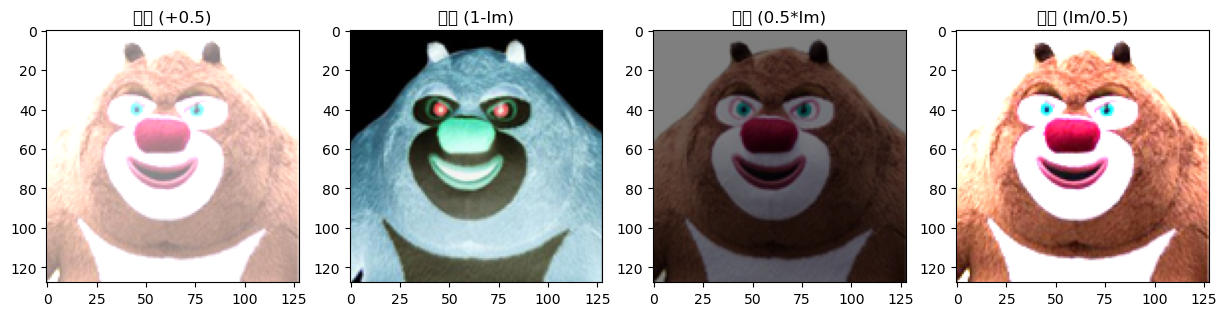

In [3]:
# [注意] 本单元格依赖步骤2中的变量 Im
from matplotlib import pyplot as plt

Im1 = Im + 0.5    # 加亮
Im2 = 1 - Im      # 反色
Im3 = 0.5 * Im    # 变暗
Im4 = Im / 0.5    # 增强亮度

plt.figure()
fig, ax = plt.subplots(1, 4)
fig.set_figwidth(15)
ax[0].imshow(Im1)
ax[0].set_title('加亮 (+0.5)')
ax[1].imshow(Im2)
ax[1].set_title('反色 (1-Im)')
ax[2].imshow(Im3)
ax[2].set_title('变暗 (0.5*Im)')
ax[3].imshow(Im4)
ax[3].set_title('增强 (Im/0.5)')
plt.show()

### 步骤4：读取CSV表格数据

**CSV（Comma-Separated Values，逗号分隔值）** 是最常见的结构化数据格式，可以用Excel或文本编辑器打开。每一行是一条记录，列之间用逗号分隔。

**Pandas** 是Python中最强大的数据分析库，其核心数据结构 `DataFrame` 类似于Excel表格，支持灵活的数据查询、统计和可视化。

**关键函数说明**：
- `pd.read_csv()` ：读取CSV文件，自动解析列名和数据类型，返回DataFrame
- `.shape` ：查看数据形状（行数, 列数）
- `.head()` ：预览前5行数据
- `.hist()` ：为每列数据绘制直方图，快速了解数据分布
- `.reshape([N, 1])` ：将一维数组 `(N,)` 重塑为二维列向量 `(N, 1)`，满足后续函数的输入格式要求

> **注意**：本步骤需要本地CSV文件 `./FoodScore.csv`，请确保该文件存在。

In [ ]:
# [注意] 本单元格需要本地CSV文件 ./FoodScore.csv
import pandas as pd
import numpy as np

# 读取CSV文件
MasterFile = pd.read_csv('./FoodScore.csv')
print("数据形状:", MasterFile.shape)
MasterFile.head()

In [ ]:
# [注意] 本单元格依赖上一单元格中的变量 MasterFile
from matplotlib import pyplot as plt

# 查看数据分布
MasterFile.hist()
plt.show()

# 提取文件名和标签
FileNames = MasterFile['ID']
N = len(FileNames)
Y = np.array(MasterFile['score']).reshape([N, 1])
print("样本数量:", N)

### 步骤5：批量读取图片数据集

当数据集包含多张图片时，需要循环读取并存入一个统一的NumPy数组中。这是深度学习中加载自定义图片数据集的基本模式。

**核心思路**：
1. **预分配数组**：使用 `np.zeros()` 提前创建一个全零数组 `X`，形状为 `(样本数, 高, 宽, 通道)`。预分配内存比在循环中动态拼接（如 `np.append`）效率高得多，因为NumPy数组大小固定，动态拼接需要反复申请内存和复制数据。
2. **循环读取**：遍历所有图片文件名，逐张打开、缩放、归一化。
3. **填入数组**：将处理好的图片存入预分配数组的对应位置 `X[i,]`。

最终得到的 `X` 是一个4维张量，可以直接输入神经网络进行训练。

> **注意**：本步骤需要本地图片文件夹 `./data_foodscore/`，请确保该文件夹及对应图片存在。

In [ ]:
# [注意] 本单元格需要本地图片文件夹 ./data_foodscore/ 和前面步骤中的变量 N, FileNames
from PIL import Image
import numpy as np

IMSIZE = 128
X = np.zeros([N, IMSIZE, IMSIZE, 3])

for i in range(N):
    MyFile = FileNames[i]
    Im = Image.open('./data_foodscore/' + MyFile + '.jpg')
    Im = Im.resize([IMSIZE, IMSIZE])
    Im = np.array(Im) / 255
    X[i,] = Im

print("图片数据集形状:", X.shape)

### 步骤6：划分训练集和测试集

**为什么要划分数据？** 这是机器学习中最重要的原则之一。如果用全部数据训练模型，模型可能出现**过拟合（Overfitting）**——即模型"死记硬背"了训练数据（包括噪声和个别样本的特殊性），在训练集上表现优秀，但遇到新数据时表现很差。

通过划分出独立的测试集，我们可以评估模型在**从未见过的数据**上的表现，即模型的**泛化能力（Generalization）**。

**`train_test_split` 参数说明**：
- `test_size=0.5`：测试集占总数据的50%。实际项目中常用 `0.2`（80%训练/20%测试）
- `random_state=0`：随机种子，保证每次运行划分结果一致，便于实验复现

注意新旧写法的区别：
- **[旧写法]** `from sklearn.cross_validation import train_test_split` —— sklearn 0.18 中已废弃，0.20 中已移除
- **[新写法]** `from sklearn.model_selection import train_test_split` —— 适用于 sklearn >= 0.18

In [ ]:
# [旧写法] from sklearn.cross_validation import train_test_split
# ↑ sklearn.cross_validation 在 sklearn 0.18 中已废弃，0.20 中已移除

# [新写法] 适用于 sklearn >= 0.18
from sklearn.model_selection import train_test_split

# 注意：此处 X, Y 来自步骤5，如果未执行步骤5可跳过本单元格
X0, X1, Y0, Y1 = train_test_split(X, Y, test_size=0.5, random_state=0)
print("训练集:", X0.shape, Y0.shape)
print("测试集:", X1.shape, Y1.shape)

### 步骤7：加载MNIST内置数据集

**MNIST** 是深度学习领域最经典的入门数据集，被称为"机器学习的Hello World"。它包含手写数字（0～9）的灰度图片：

| 项目 | 说明 |
|------|------|
| 训练集 | **60,000** 张图片 |
| 测试集 | **10,000** 张图片 |
| 图片尺寸 | **28×28** 像素，单通道灰度图 |
| 类别数 | **10** 个（数字0～9） |

**`reshape(-1, 784)` 说明**：全连接神经网络要求输入为一维向量，因此需要将 `28×28` 的二维图片"展平"为长度为 `784`（= 28×28）的一维向量。参数 `-1` 是NumPy的特殊值，表示"自动推断该维度的大小"——NumPy会根据总元素数除以其他维度来计算，此处 `-1` 会被计算为样本数量（60000或10000）。

注意新旧写法的区别：
- **[旧写法]** `from tensorflow.examples.tutorials.mnist import input_data` —— TF 1.x 教程接口，已废弃
- **[新写法]** `from tensorflow.keras.datasets import mnist` —— 适用于 TF >= 2.0

> 本步骤使用TensorFlow内置的MNIST数据集，无需额外数据文件，可直接运行。

In [7]:
# [旧写法] TensorFlow 1.x 教程接口（已废弃）
# from tensorflow.examples.tutorials.mnist import input_data
# data = input_data.read_data_sets("data/MNIST/", one_hot=False)

# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.datasets import mnist

(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print("原始训练集形状:", X_train.shape)  # (60000, 28, 28)
print("原始测试集形状:", X_test.shape)   # (10000, 28, 28)

# 展平 + 归一化
X_train = X_train.reshape(-1, 28 * 28).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28 * 28).astype("float32") / 255.0

print("展平后训练集形状:", X_train.shape)  # (60000, 784)
print("展平后测试集形状:", X_test.shape)   # (10000, 784)

原始训练集形状: (60000, 28, 28)
原始测试集形状: (10000, 28, 28)
展平后训练集形状: (60000, 784)
展平后测试集形状: (10000, 784)


#### MNIST数据可视化

查看MNIST数据集中的前几张手写数字图片：

/tmp/ipykernel_17135/66542773.py:9: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17135/66542773.py:9: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gawainli/miniconda/envs/tf-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gawainli/miniconda/envs/tf-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


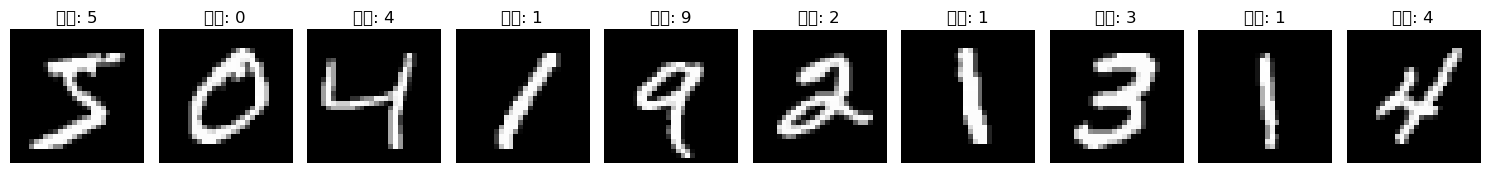

In [8]:
import matplotlib.pyplot as plt

# 可视化前10张图片
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'标签: {Y_train[i]}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### 步骤8：使用ImageDataGenerator从文件夹读取数据

**ImageDataGenerator** 是Keras提供的图片数据生成器，特别适合处理大规模图片数据集。与步骤5中"一次性全部加载到内存"的方式不同，ImageDataGenerator采用**按需加载（lazy loading）**的策略：

- **内存高效**：不需要将所有图片一次性读入内存，而是每次只加载一个批次（batch），训练完当前批次后再加载下一批。对于包含数万甚至数十万张图片的数据集，这种方式可以大大减少内存占用。
- **自动预处理**：通过 `rescale=1./255` 参数自动完成归一化，无需手动操作。
- **自动标注**：`flow_from_directory` 会根据子文件夹名称自动确定类别标签。例如 `data/train/cat/` 下的图片自动标注为"cat"类。
- **`class_mode='categorical'`**：标签格式为One-Hot编码，适用于多分类任务。
- **`target_size`**：自动将所有图片缩放到统一尺寸。

注意新旧写法的区别：
- **[旧写法]** `from keras.preprocessing.image import ImageDataGenerator` —— 独立 keras 包在 TF 2.0+ 中已不推荐使用
- **[新写法]** `from tensorflow.keras.preprocessing.image import ImageDataGenerator` —— 适用于 TF >= 2.0

> **注意**：本步骤需要按类别组织好的图片文件夹 `data/train/` 和 `data/test/`。

In [5]:
# [注意] 本单元格需要本地文件夹 data/train/ 和 data/test/

# [旧写法] from keras.preprocessing.image import ImageDataGenerator
# ↑ 独立 keras 包在 TF 2.0+ 中已不推荐使用

# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMSIZE = 227

train_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'data/train/',
    target_size=(IMSIZE, IMSIZE),
    batch_size=200,
    class_mode='categorical')

validation_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'data/test/',
    target_size=(IMSIZE, IMSIZE),
    batch_size=200,
    class_mode='categorical')

# 查看一个批次的数据
X, Y = next(train_generator)
print("批次数据形状:", X.shape, Y.shape)

Found 0 images belonging to 0 classes.
Found 0 images belonging to 0 classes.
批次数据形状: (0, 227, 227, 3) (0, 0)


### 步骤9：数据增强

**数据增强（Data Augmentation）** 是通过对训练图片施加随机变换来人为扩大训练集多样性的技术。它是防止过拟合、提高模型泛化能力的重要手段。

ImageDataGenerator支持多种数据增强方式，每种变换模拟了现实中拍照时的不同情况：

| 参数 | 含义 | 直觉理解 |
|------|------|----------|
| `shear_range=0.5` | 剪切变换，最大0.5弧度 | 将图片沿对角方向拉伸，矩形变为平行四边形 |
| `rotation_range=30` | 随机旋转±30° | 模拟物体以不同角度出现 |
| `zoom_range=0.2` | 随机缩放0.8～1.2倍 | 模拟物体远近不同 |
| `width_shift_range=0.2` | 水平平移最多20% | 模拟物体不在画面中央 |
| `height_shift_range=0.2` | 垂直平移最多20% | 同上，垂直方向 |
| `horizontal_flip=True` | 随机水平翻转 | 适用于左右对称物体（如猫、狗），不适用于文字 |

**重要**：数据增强仅应用于**训练集**，测试集/验证集不做增强，以保证评估结果的客观性。

> **注意**：本步骤需要本地图片文件夹 `data/train/`。

In [ ]:
# [注意] 本单元格需要本地文件夹 data/train/
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMSIZE = 227

train_generator = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.5,       # 剪切变换
    rotation_range=30,     # 随机旋转角度
    zoom_range=0.2,        # 随机缩放
    width_shift_range=0.2, # 水平平移
    height_shift_range=0.2,# 垂直平移
    horizontal_flip=True   # 水平翻转
).flow_from_directory(
    'data/train/',
    target_size=(IMSIZE, IMSIZE),
    batch_size=200,
    class_mode='categorical')

print("数据增强生成器创建成功")

### 步骤10：One-Hot编码

在分类任务中，标签需要从整数形式转换为 **One-Hot编码**。One-Hot编码将每个类别表示为一个向量，其中只有对应位置为1，其余全为0。

**具体示例**（以MNIST的10个类别为例）：

| 原始标签 | One-Hot编码 |
|----------|-------------|
| 0 | `[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]` |
| 1 | `[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]` |
| 3 | `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]` |
| 9 | `[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]` |

**为什么需要One-Hot？** 如果直接使用整数标签（0, 1, 2, ...），模型可能误认为 `3 > 1`，即标签之间存在大小关系。但分类标签实际上是**无序的类别**。One-Hot编码消除了这种隐含的数值关系。

神经网络输出层通常使用 **Softmax** 激活函数，输出每个类别的概率（加起来等于1），与One-Hot标签格式匹配，使用**交叉熵损失函数**计算预测与真实标签之间的误差。

注意新旧写法的区别：
- **[旧写法]** `from keras.utils import to_categorical` 或 `from keras.utils import np_utils; np_utils.to_categorical(Y)` —— 独立 keras 包及 np_utils 在 TF 2.0+ 中已不推荐/已移除
- **[新写法]** `from tensorflow.keras.utils import to_categorical` —— 适用于 TF >= 2.0

> 本步骤使用步骤7中加载的MNIST标签数据，可直接运行。

In [9]:
# [旧写法] from keras.utils import to_categorical
# [旧写法] from keras.utils import np_utils; np_utils.to_categorical(Y)
# ↑ 独立 keras 包及 np_utils 在 TF 2.0+ 中已不推荐/已移除

# [新写法] 适用于 TensorFlow >= 2.0
from tensorflow.keras.utils import to_categorical

YY_train = to_categorical(Y_train)
YY_test = to_categorical(Y_test)
print("One-Hot训练标签形状:", YY_train.shape)  # (60000, 10)
print("One-Hot测试标签形状:", YY_test.shape)   # (10000, 10)

# 查看示例
print("\n原始标签:", Y_train[:5])
print("One-Hot编码:")
print(YY_train[:5])

One-Hot训练标签形状: (60000, 10)
One-Hot测试标签形状: (10000, 10)

原始标签: [5 0 4 1 9]
One-Hot编码:
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


## 五、新旧写法对照总表

| 功能 | 旧写法 (TF 1.x / 独立keras) | 新写法 (TF 2.x) |
|------|------|------|
| 数据集加载 | `tensorflow.examples.tutorials.mnist` | `tensorflow.keras.datasets.mnist` |
| 图片生成器 | `from keras.preprocessing.image import ImageDataGenerator` | `from tensorflow.keras.preprocessing.image import ImageDataGenerator` |
| One-Hot编码 | `from keras.utils import np_utils` | `from tensorflow.keras.utils import to_categorical` |
| 数据划分 | `from sklearn.cross_validation import train_test_split` | `from sklearn.model_selection import train_test_split` |
| Session执行 | `session = tf.Session(); session.run(x)` | `x.numpy()` (Eager Execution) |
| 训练模型 | `model.fit_generator(generator, ...)` | `model.fit(generator, ...)` |

## 六、思考题

1. TensorFlow 1.x与2.x的最大区别是什么？为什么2.x更适合教学？
2. 为什么要对图片进行归一化处理？如果不归一化会怎样？
3. `train_test_split`中的`random_state`参数有什么作用？
4. `ImageDataGenerator`中的数据增强有哪些方式？各适用于什么场景？